In [1]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
cell_type_mapping_file="/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/LeafletFA_Supplemental_Table_1.xlsx" 
# read the excel file 
cell_type_mapping = pd.read_excel(cell_type_mapping_file)
cell_type_mapping.head()

,cell_id,cell_name,cell_ontology_class,broad_cell_type,tissue,tissue_celltype,dataset
0,A10_B000120,A10_B000120,basal epithelial cell of tracheobronchial tree,Epithelial,Trachea,Trachea_Epithelial,TMS
1,A10_B000126,A10_B000126,bulge keratinocyte,Epithelial,Skin,Skin_Keratinocyte,TMS
2,A10_B000127,A10_B000127,myeloid cell,Immune,SCAT,SCAT_Myeloid,TMS
3,A10_B000166,A10_B000166,basal cell,Epithelial,Mammary_Gland,Mammary_Epithelial,TMS
4,A10_B000169,A10_B000169,endothelial cell of coronary artery,Endothelial,Heart,Heart_VascEndo,TMS


In [3]:
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
SPLICE_INPUT = f"{BASE_DIR}/MODEL_INPUT/102025/model_ready_aligned_splicing_data_20251009_024406.h5ad"

# Read the splicing data
splice_adata = ad.read_h5ad(SPLICE_INPUT)
splice_adata

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 142315 × 89831
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions'
    var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influence'
    obsm: 'X_library_size'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix'

In [4]:
# remove all the old colummns in splice_adata.obs other than cell_id and cell_name that are in cell_type_mapping
# find columns in cell_type_mapping that are in splice_adata.obs
columns_to_drop = [col for col in cell_type_mapping.columns if col in splice_adata.obs.columns] 
# remove cell_id and cell_name from columns_to_drop
columns_to_drop.remove("cell_id")
columns_to_drop.remove("cell_name")
print(columns_to_drop)

['cell_ontology_class', 'broad_cell_type', 'tissue', 'dataset']


In [5]:
# remove columns from splice_adata.obs
splice_adata.obs.drop(columns=columns_to_drop, inplace=True)
# reset index of splice_adata.obs
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs = pd.merge(splice_adata.obs, cell_type_mapping, on=["cell_id", "cell_name"], how="left")

# check that splice_adata.obs.index is exactly the same as splice_adata.obs["cell_id_index"]
assert np.all(splice_adata.obs.index == splice_adata.obs["cell_id_index"]), "Index of splice_adata.obs is not exactly the same as cell_id_index"
splice_adata.obs_names = splice_adata.obs["cell_id"]

In [6]:
splice_adata

AnnData object with n_obs × n_vars = 142315 × 89831
    obs: 'cell_id_index', 'age', 'mouse.id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset'
    var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influence'
    obsm: 'X_library_size'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix'

In [7]:
# Save the splicing data to BASE_DIR named Figure1_input_data.h5ad
splice_adata.write_h5ad(f"{BASE_DIR}/Figure1_input_data.h5ad")

In [8]:
print(f"Done saving the splicing data to {BASE_DIR}/Figure1_input_data.h5ad")

Done saving the splicing data to /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/Figure1_input_data.h5ad


In [9]:
output_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs"

In [10]:
all_juncs_df = splice_adata.var

/scratch/ipykernel_2819860/1975994707.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  k_per_event = all_juncs_df.groupby("event_id")["junction_id"].nunique()


Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/junctions_per_ATSE_barplot.pdf


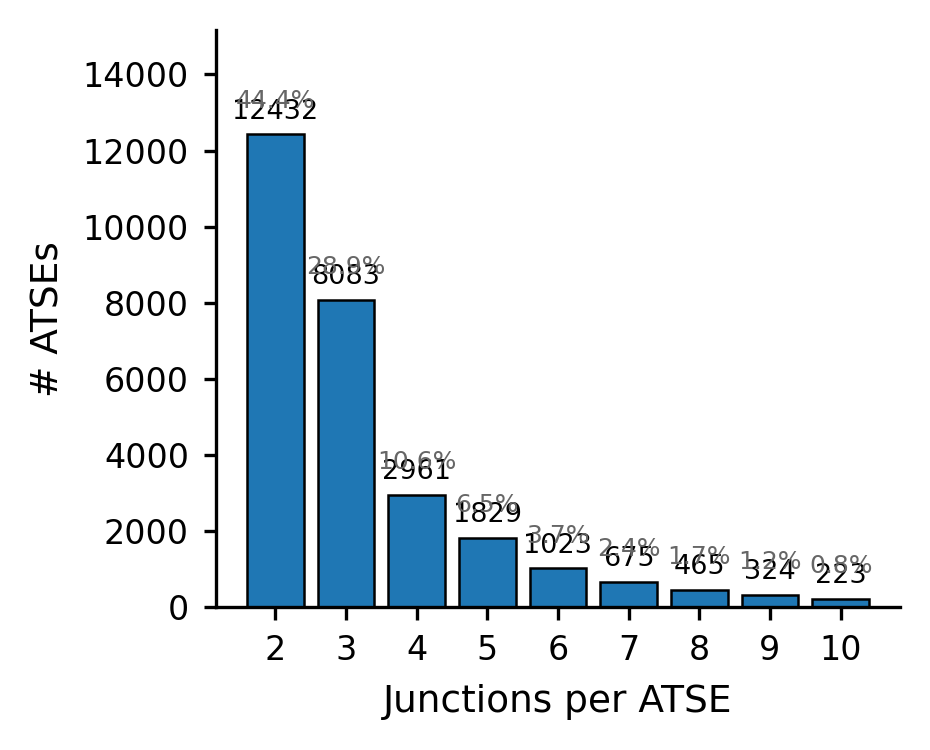

In [11]:
import os 

# ---- Compute junctions-per-ATSE ----
k_per_event = all_juncs_df.groupby("event_id")["junction_id"].nunique()
dist = k_per_event.value_counts().sort_index()
x = dist.index.to_numpy()
y = dist.to_numpy()
perc = (dist / dist.sum() * 100)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(3.2, 2.6), dpi=300)
bars = ax.bar(x, y, width=0.8, edgecolor="black", linewidth=0.6)

# annotations: count (black) and percent (grey), smaller fonts
y_pad = max(1, int(y.max() * 0.02))
for xi, yi, pi in zip(x, y, perc):
    ax.text(xi, yi + y_pad, f"{yi}", ha="center", va="bottom", fontsize=6.5)
    ax.text(xi, yi + y_pad*2.2, f"{pi:.1f}%", ha="center", va="bottom",
            fontsize=6, color="0.4")  # grey

ax.set_xlabel("Junctions per ATSE", fontsize=9)
ax.set_ylabel("# ATSEs", fontsize=9)
ax.set_xticks(x)
ax.set_ylim(0, y.max() * 1.22)

# minimal styling
ax.tick_params(axis="both", labelsize=8, length=3)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# ---- Save ----
output_file = os.path.join(output_dir, "junctions_per_ATSE_barplot.pdf")
plt.savefig(output_file, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

In [13]:
all_juncs_df["junction_id"].nunique(), all_juncs_df["event_id"].nunique(), all_juncs_df["gene_name"].nunique()

(89831, 28015, 10572)

/scratch/ipykernel_2819860/2725300530.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  atses_per_gene = all_juncs_df.groupby("gene_id")["event_id"].nunique()


Total genes: 10572
Total ATSEs: 28015
Mean ATSEs per gene: 2.65
Median ATSEs per gene: 2.0
Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs/ATSEs_per_gene_barplot.pdf


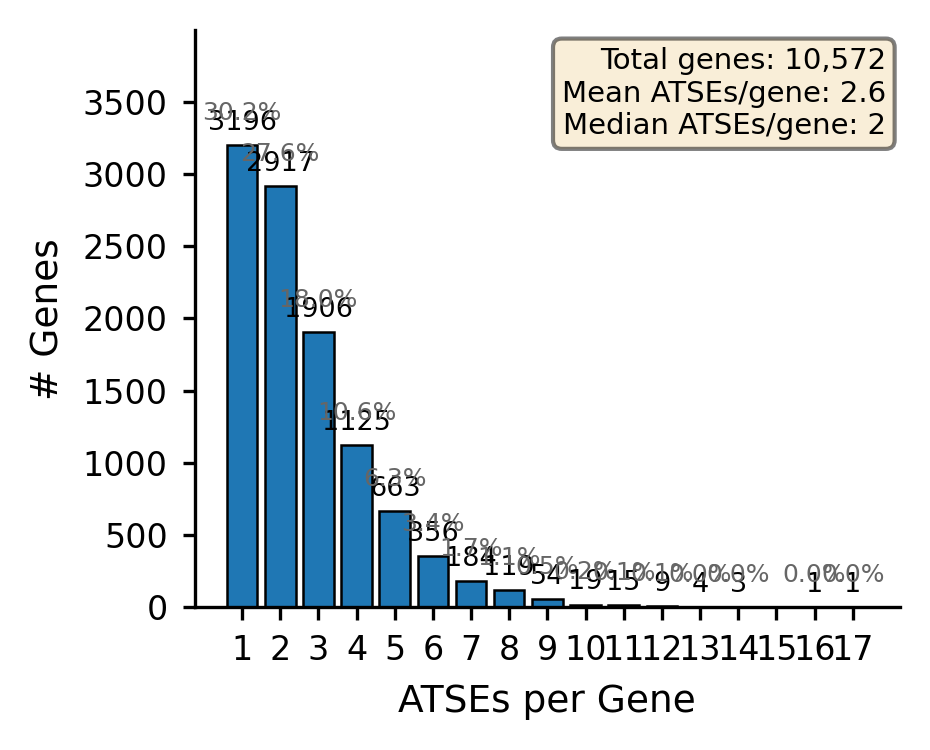


Top 10 genes with most ATSEs:
  ENSMUSG00000051166.10: 17 ATSEs
  ENSMUSG00000029478.16: 16 ATSEs
  ENSMUSG00000058740.14: 14 ATSEs
  ENSMUSG00000061751.16: 14 ATSEs
  ENSMUSG00000068457.14: 14 ATSEs
  ENSMUSG00000012609.19: 13 ATSEs
  ENSMUSG00000032826.19: 13 ATSEs
  ENSMUSG00000044072.14: 13 ATSEs
  ENSMUSG00000053477.17: 13 ATSEs
  ENSMUSG00000001127.12: 12 ATSEs


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# ---- Compute ATSEs-per-gene ----
atses_per_gene = all_juncs_df.groupby("gene_id")["event_id"].nunique()
dist = atses_per_gene.value_counts().sort_index()

# FIX: Reindex to include all integers from 1 to max, filling missing values with 0
# This ensures that "15" shows up on your x-axis even if no gene has 15 events.
full_range = range(1, int(dist.index.max()) + 1)
dist = dist.reindex(full_range, fill_value=0)

x = dist.index.to_numpy()
y = dist.to_numpy()
perc = (dist / dist.sum() * 100)

# Calculate summary statistics
total_genes = atses_per_gene.shape[0]
total_atses = atses_per_gene.sum()
mean_atses = atses_per_gene.mean()
median_atses = atses_per_gene.median()

print(f"Total genes: {total_genes}")
print(f"Total ATSEs: {total_atses}")
print(f"Mean ATSEs per gene: {mean_atses:.2f}")
print(f"Median ATSEs per gene: {median_atses:.1f}")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(3.2, 2.6), dpi=300)

max_atses = x.max()

if max_atses > 20:
    # Group larger values into bins for cleaner visualization
    bins = list(range(1, 21)) + [25, 30, 40, 50, 75, 100, 150, 200, max_atses+1]
    binned_counts = pd.cut(atses_per_gene, bins=bins, right=False, include_lowest=True)
    dist_binned = binned_counts.value_counts().sort_index()
    
    labels = []
    for interval in dist_binned.index:
        if interval.right - interval.left == 1:
            labels.append(f"{int(interval.left)}")
        elif interval.right == max_atses+1:
            labels.append(f"{int(interval.left)}+")
        else:
            labels.append(f"{int(interval.left)}-{int(interval.right-1)}")
    
    bars = ax.bar(range(len(dist_binned)), dist_binned.values, width=0.8, 
                  edgecolor="black", linewidth=0.6)
    ax.set_xticks(range(len(dist_binned)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    
    # Annotations for binned data
    y_pad = max(1, int(dist_binned.values.max() * 0.02))
    for i, (count, pct) in enumerate(zip(dist_binned.values, dist_binned.values/dist_binned.sum()*100)):
        if count > 0: 
            ax.text(i, count + y_pad, f"{count}", ha="center", va="bottom", fontsize=6.5)
            ax.text(i, count + y_pad*2.2, f"{pct:.1f}%", ha="center", va="bottom",
                   fontsize=6, color="0.4")
    
    ax.set_ylim(0, dist_binned.values.max() * 1.25)
    
else:
    # For smaller range (your current case), plot each value individually
    bars = ax.bar(x, y, width=0.8, edgecolor="black", linewidth=0.6)
    
    # Annotations: count (black) and percent (grey)
    y_pad = max(1, int(y.max() * 0.02))
    for xi, yi, pi in zip(x, y, perc):
        # Only add text labels if the count is greater than 0
        if yi > 0:
            ax.text(xi, yi + y_pad, f"{int(yi)}", ha="center", va="bottom", fontsize=6.5)
            ax.text(xi, yi + y_pad*2.2, f"{pi:.1f}%", ha="center", va="bottom",
                    fontsize=6, color="0.4")
    
    ax.set_xticks(x)
    ax.set_ylim(0, y.max() * 1.25)

# Axis labels and styling
ax.set_xlabel("ATSEs per Gene", fontsize=9)
ax.set_ylabel("# Genes", fontsize=9)

# Summary text box
textstr = f'Total genes: {total_genes:,}\nMean ATSEs/gene: {mean_atses:.1f}\nMedian ATSEs/gene: {median_atses:.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=7,
        verticalalignment='top', horizontalalignment='right', bbox=props)

ax.tick_params(axis="both", labelsize=8, length=3)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# ---- Save and Show ----
output_file = os.path.join(output_dir, "ATSEs_per_gene_barplot.pdf")
plt.savefig(output_file, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

# ---- Top genes ----
top_genes = atses_per_gene.nlargest(10)
print(f"\nTop 10 genes with most ATSEs:")
for gene, n_atses in top_genes.items():
    print(f"  {gene}: {n_atses} ATSEs")